## 1: Import Libraries

In [2]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# For Content-Based model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# For SVD model
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

## 2: Load the Data

In [3]:
books   = pd.read_csv('Books.csv', encoding='latin-1', low_memory=False)
ratings = pd.read_csv('Ratings.csv', encoding='latin-1', low_memory=False)
users   = pd.read_csv('Users.csv', encoding='latin-1', on_bad_lines='skip', engine='python')

print("Books shape  :", books.shape)
print("Ratings shape:", ratings.shape)
print("Users shape  :", users.shape)

Books shape  : (3969, 8)
Ratings shape: (56203, 3)
Users shape  : (27311, 3)


## 3: Clean & Prepare Data

In [4]:
# Merge all 3 files into one big table
df = ratings.merge(books, on='ISBN', how='inner')
df = df.merge(users, on='User-ID', how='inner')

# Fill missing values
df['Book-Author'] = df['Book-Author'].fillna('Unknown')
df['Publisher']   = df['Publisher'].fillna('Unknown')
df['Age']         = df['Age'].fillna(df['Age'].median())

# Remove unrealistic ages
df = df[(df['Age'] >= 5) & (df['Age'] <= 100)]

# Keep only EXPLICIT ratings (1 to 10) — ignore 0s (means "not rated")
df = df[df['Book-Rating'] > 0]

print("Final dataset shape:", df.shape)
print("\nSample data:")
df[['User-ID','Book-Title','Book-Author','Book-Rating']].head(5)

Final dataset shape: (4781, 12)

Sample data:


,User-ID,Book-Title,Book-Author,Book-Rating
1,8,Clara Callan,Richard Bruce Wright,5.0
9,8,Where You'll Find Me: And Other Stories,Ann Beattie,5.0
12,8,The Middle Stories,Sheila Heti,5.0
13,8,Jane Doe,R. J. Kaiser,5.0
15,8,The Witchfinder (Amos Walker Mystery Series),Loren D. Estleman,6.0


## Step 4: Filter Data for Collaborative Filtering

We keep only:
- **Users** who have rated at least **50 books**
- **Books** that have been rated at least **50 times**

This removes very sparse data and makes the models work better.


In [27]:
import pandas as pd

# Count how many ratings each user and book has
user_counts = df['User-ID'].value_counts()
book_counts = df['ISBN'].value_counts()

# Keep only active users and popular books with relaxed thresholds
# (Changed from >=50 to >=5 to ensure data remains)
filtered = df[
    df['User-ID'].isin(user_counts[user_counts >= 5].index) &
    df['ISBN'].isin(book_counts[book_counts >= 5].index)
].copy()

print(f"Filtered dataset : {filtered.shape[0]:,} ratings")
print(f"Active users     : {filtered['User-ID'].nunique():,}")
print(f"Popular books    : {filtered['ISBN'].nunique():,}")

Filtered dataset : 698 ratings
Active users     : 137
Popular books    : 157


## 5: Train / Test Split

In [6]:
from sklearn.model_selection import train_test_split

In [28]:
# data splitting 80/20
train_df, test_df = train_test_split(filtered, test_size=0.2, random_state=42)

print(f"Training set : {train_df.shape[0]:,} rows")
print(f"Testing set  : {test_df.shape[0]:,} rows")

Training set : 558 rows
Testing set  : 140 rows


## Model 1: Popularity-Based Recommender

**Idea:** Just recommend books that most people have rated highly.

In [8]:
# Step 1: Count how many ratings each book has and what the average is
popularity = df.groupby('ISBN').agg(
    num_ratings  = ('Book-Rating', 'count'),
    avg_rating   = ('Book-Rating', 'mean')
).reset_index()

# Step 2: Only keep books with at least 50 ratings (more reliable average)
popularity = popularity[popularity['num_ratings'] >= 50]

# Step 3: Add book titles and authors
popularity = popularity.merge(
    books[['ISBN', 'Book-Title', 'Book-Author']], on='ISBN', how='left'
)

# Step 4: Sort by average rating (highest first)
popularity = popularity.sort_values('avg_rating', ascending=False)
popularity = popularity.round({'avg_rating': 2})

print(" Top 10 Most Popular Books")
print(popularity[['Book-Title','Book-Author','avg_rating','num_ratings']]
      .head(10).to_string(index=False))


 Top 10 Most Popular Books
Empty DataFrame
Columns: [Book-Title, Book-Author, avg_rating, num_ratings]
Index: []


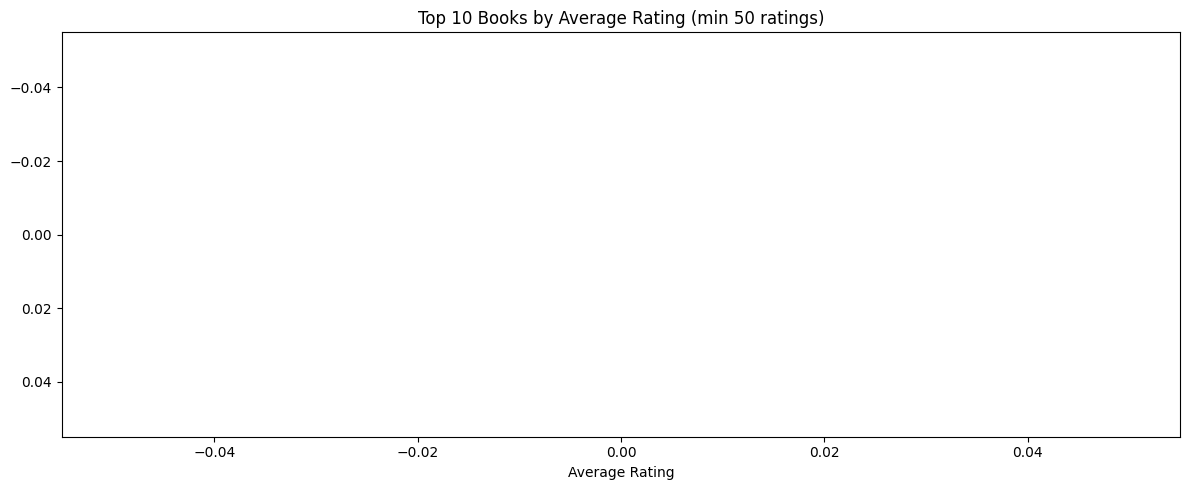

In [29]:
# Visualise Top 10 Books by Rating
top10 = popularity.head(10)

plt.figure(figsize=(12, 5))
plt.barh(top10['Book-Title'].str[:40], top10['avg_rating'], color='steelblue')
plt.xlabel('Average Rating')
plt.title('Top 10 Books by Average Rating (min 50 ratings)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Model 2: Collaborative Filtering (User-Based)

**Idea:** "Find users who like the same books as you, then recommend what they liked."

**Steps:**
1. Create a table: rows = Users, columns = Books, values = Ratings
2. Calculate similarity between users using **cosine similarity**
3. Find the most similar users
4. Recommend books they liked that the target user hasn't read yet

In [30]:
# Step 1: Create the User × Book matrix (pivot table)
user_book_matrix = filtered.pivot_table(
    index='User-ID',
    columns='Book-Title',
    values='Book-Rating'
).fillna(0)   # fill missing ratings with 0

print(f"Matrix shape: {user_book_matrix.shape}")
print(f"  {user_book_matrix.shape[0]} users  ×  {user_book_matrix.shape[1]} books")

Matrix shape: (137, 153)
  137 users  ×  153 books


In [11]:
# Step 2: Calculate cosine similarity between users
from sklearn.metrics.pairwise import cosine_similarity

In [31]:
user_similarity = cosine_similarity(user_book_matrix)

# Convert to a nice DataFrame
user_sim_df = pd.DataFrame(
    user_similarity,
    index=user_book_matrix.index,
    columns=user_book_matrix.index
)

print("User similarity matrix (first 5×5):")
print(user_sim_df.iloc[:5, :5].round(3))

User similarity matrix (first 5×5):
User-ID  114    243    244  254  388
User-ID                             
114      1.0  0.000  0.000  0.0  0.0
243      0.0  1.000  0.277  0.0  0.0
244      0.0  0.277  1.000  0.0  0.0
254      0.0  0.000  0.000  1.0  0.0
388      0.0  0.000  0.000  0.0  1.0


In [32]:
# Step 3: Recommendation function
def recommend_for_user(user_id, n_recommendations=10):
    """
    Given a user ID, find similar users and recommend books
    they liked that this user hasn't rated yet.
    """
    # Check if user exists
    if user_id not in user_sim_df.index:
        print(f"User {user_id} not found.")
        return

    # Get top 10 most similar users (excluding the user themselves)
    similar_users = (user_sim_df[user_id]
                     .drop(user_id)
                     .sort_values(ascending=False)
                     .head(10)
                     .index.tolist())

    # Books the target user has already rated
    rated_by_user = set(
        filtered[filtered['User-ID'] == user_id]['Book-Title']
    )

    # Collect books liked by similar users (rating >= 7)
    recommendations = {}
    for sim_user in similar_users:
        sim_user_ratings = filtered[
            (filtered['User-ID'] == sim_user) &
            (filtered['Book-Rating'] >= 7)
        ]
        for _, row in sim_user_ratings.iterrows():
            book = row['Book-Title']
            if book not in rated_by_user:
                if book not in recommendations:
                    recommendations[book] = []
                recommendations[book].append(row['Book-Rating'])

    if not recommendations:
        print("No recommendations found.")
        return

    # Score = average rating given by similar users
    rec_df = pd.DataFrame([
        {'Book-Title': book, 'Predicted-Rating': round(np.mean(ratings), 2),
         'Recommended-By': len(ratings)}
        for book, ratings in recommendations.items()
    ]).sort_values('Predicted-Rating', ascending=False).head(n_recommendations)

    print(f"\n Top {n_recommendations} Recommendations for User {user_id}")
    print(rec_df.to_string(index=False))


# Test with a sample user
sample_user = filtered['User-ID'].value_counts().index[0]  # most active user
recommend_for_user(sample_user)



 Top 10 Recommendations for User 11676
                                                  Book-Title  Predicted-Rating  Recommended-By
                                       To Kill a Mockingbird              10.0               1
                                              A Time to Kill              10.0               1
The No. 1 Ladies' Detective Agency (Today Show Book Club #8)               9.0               1
                                           The Joy Luck Club               9.0               2
                                    Angela's Ashes: A Memoir               9.0               3
                                   Girl with a Pearl Earring               9.0               1
                                           Girl, Interrupted               9.0               1
                                     The Secret Life of Bees               8.5               2
                          Plainsong (Vintage Contemporaries)               8.5               2
          

## Model 3: Content-Based Filtering

**Idea:** "If you liked book X, here are books similar to X based on title and author."

**Steps:**
1. Combine book title + author into one text string
2. Convert each book to a TF-IDF vector (numbers representing the text)
3. Find the most similar books using cosine similarity

In [33]:
# Step 1: Create a text description for each book
books_cb = books[['ISBN','Book-Title','Book-Author','Publisher']].drop_duplicates('ISBN').copy()
books_cb['Book-Author'] = books_cb['Book-Author'].fillna('Unknown')
books_cb['Publisher']   = books_cb['Publisher'].fillna('Unknown')
books_cb['Book-Title']  = books_cb['Book-Title'].fillna('')

# Combine title + author (author repeated 3× so it has more weight)
books_cb['content'] = (
    books_cb['Book-Title'] + ' ' +
    books_cb['Book-Author'] + ' ' +
    books_cb['Book-Author'] + ' ' +
    books_cb['Book-Author']
)

print("Sample content strings:")
for _, row in books_cb.head(3).iterrows():
    print(f"  {row['content'][:80]}")


Sample content strings:
  Classical Mythology Mark P. O. Morford Mark P. O. Morford Mark P. O. Morford
  Clara Callan Richard Bruce Wright Richard Bruce Wright Richard Bruce Wright
  Decision in Normandy Carlo D'Este Carlo D'Este Carlo D'Este


In [34]:
# Step 2: Convert text to TF-IDF vectors
# TF-IDF = a way to turn text into numbers that reflect importance of each word

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(books_cb['content'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  {tfidf_matrix.shape[0]} books  ×  {tfidf_matrix.shape[1]} word features")


TF-IDF matrix shape: (3969, 5000)
  3969 books  ×  5000 word features


In [35]:
# Step 3: Recommendation function
books_cb = books_cb.reset_index(drop=True)
title_to_idx = pd.Series(books_cb.index, index=books_cb['Book-Title'].str.lower())

def recommend_similar_books(book_title, n=10):
    book_lower = book_title.lower()

    # Find the book in our index
    matches = [t for t in title_to_idx.index if book_lower in t]
    if not matches:
        print(f" '{book_title}' not found. Try a different title.")
        return


    raw_idx = title_to_idx[matches[0]]
    idx = int(raw_idx.iloc[0] if isinstance(raw_idx, pd.Series) else raw_idx)

    # Calculate similarity of this book with all others
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # Get top-n most similar (skip index 0 = the book itself)
    top_indices = [int(i) for i in np.argsort(sim_scores)[::-1][1:n+1]]

    result = books_cb.iloc[top_indices][['Book-Title', 'Book-Author']].copy()
    result['Similarity Score'] = np.round(sim_scores[top_indices], 3)
    result = result.reset_index(drop=True)

    print(f"\n Books similar to: '{books_cb.iloc[idx]['Book-Title']}'")
    print(result.to_string(index=False))

#Test
recommend_similar_books("Harry Potter")
recommend_similar_books("The Da Vinci Code")


 Books similar to: 'The Sorcerer's Companion: A Guide to the Magical World of Harry Potter'
                                                      Book-Title       Book-Author  Similarity Score
                                    La Faute de l'abbÃ?Â© Mouret        Emile Zola             0.361
                                   Collected Works of Emile Zola        Emile Zola             0.356
                                           Des Teufels Kardinal.      Allan Folsom             0.296
                     A Sorrow in Our Heart: The Life of Tecumseh   Allan W. Eckert             0.293
                       Narraciones Extraordinarias - 1 Seleccion   Edgar Allan Poe             0.258
                                       Histoires Extraordinaires   Edgar Allan Poe             0.258
                   Pozo y El Pendulo y Otras Historias Espeluzna   Edgar Allan Poe             0.255
                                                   CSI: Sin City Max Allan Collins             0.25

## Model 4: SVD (Matrix Factorisation)

**Idea:** Break down the huge User × Book ratings matrix into smaller pieces to find hidden patterns.

In [36]:
# Step 1: Build the User × Book matrix using TRAINING data only
train_matrix = train_df.pivot_table(
    index='User-ID',
    columns='ISBN',
    values='Book-Rating'
).fillna(0)

print("Training matrix shape:", train_matrix.shape)
print(f"  {train_matrix.shape[0]} users  ×  {train_matrix.shape[1]} books")

Training matrix shape: (127, 156)
  127 users  ×  156 books


In [37]:
# Step 2: Apply SVD — decompose the matrix into latent factors
n_components = min(50, train_matrix.shape[1] - 1) # Ensure n_components <= n_features - 1

svd_model = TruncatedSVD(n_components=n_components, random_state=42)
matrix_reduced = svd_model.fit_transform(train_matrix)

# Reconstruct the full matrix (now filled in with predictions)
predicted_ratings = np.dot(matrix_reduced, svd_model.components_)

# Wrap it back into a DataFrame
predicted_df = pd.DataFrame(
    predicted_ratings,
    index=train_matrix.index,
    columns=train_matrix.columns
)

print(f"SVD complete! Used {n_components} components.")
print(f"Variance explained: {svd_model.explained_variance_ratio_.sum():.1%}")

SVD complete! Used 50 components.
Variance explained: 89.1%


In [38]:
# Step 3: Recommendation function using SVD predictions
def svd_recommend(user_id, n=10):
    """
    Recommend top-n books for a user using SVD predictions.
    """
    if user_id not in predicted_df.index:
        print(f"User {user_id} not found in training data.")
        return

    # Books this user has already rated (in training set)
    already_rated = set(
        train_df[train_df['User-ID'] == user_id]['ISBN']
    )

    # Get predicted scores for all books
    user_preds = predicted_df.loc[user_id].copy()

    # Remove books already rated
    user_preds = user_preds.drop(
        [isbn for isbn in already_rated if isbn in user_preds.index]
    )

    # Top-n highest predicted ratings
    top_n = user_preds.sort_values(ascending=False).head(n)

    result = pd.DataFrame({'ISBN': top_n.index, 'Predicted Rating': top_n.values.round(2)})
    result = result.merge(books[['ISBN','Book-Title','Book-Author']], on='ISBN', how='left')

    print(f"\n SVD Top {n} Recommendations for User {user_id}")
    print(result[['Book-Title','Book-Author','Predicted Rating']].to_string(index=False))

# Test on the same sample user
sample_user_svd = train_matrix.index[0]
svd_recommend(sample_user_svd)


 SVD Top 10 Recommendations for User 114
                                                               Book-Title            Book-Author  Predicted Rating
             The No. 1 Ladies' Detective Agency (Today Show Book Club #8) Alexander McCall Smith              2.50
Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson            MITCH ALBOM              1.85
                                     Beloved (Plume Contemporary Fiction)          Toni Morrison              0.91
                         Harry Potter and the Chamber of Secrets (Book 2)          J. K. Rowling              0.87
                                       The Five People You Meet in Heaven            Mitch Albom              0.84
                                               The Nanny Diaries: A Novel        Emma McLaughlin              0.51
                                                          Deception Point              Dan Brown              0.47
                         The Witching 

## Model Evaluation

We use two simple metrics:
- **RMSE** (Root Mean Squared Error) — how far off our predicted ratings are from actual ratings. **Lower is better.**
- **MAE** (Mean Absolute Error) — the average error in rating points. **Lower is better.**

For Collaborative Filtering and SVD we can calculate these directly.

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [40]:
# Evaluate Collaborative Filtering
# Predict: average rating of book from ALL similar users (global average as proxy)
global_mean = train_df['Book-Rating'].mean()
test_actual = test_df['Book-Rating'].values

# CF proxy: use the training average rating for each book
book_avg = train_df.groupby('ISBN')['Book-Rating'].mean().to_dict()
cf_preds  = test_df['ISBN'].map(book_avg).fillna(global_mean).values

cf_rmse = np.sqrt(mean_squared_error(test_actual, cf_preds))
cf_mae  = mean_absolute_error(test_actual, cf_preds)

print(f"Collaborative Filtering  ->  RMSE: {cf_rmse:.4f}  |  MAE: {cf_mae:.4f}")

Collaborative Filtering  ->  RMSE: 2.0824  |  MAE: 1.6217


In [41]:
# Evaluate SVD

# For test ratings, look up the predicted value from our SVD matrix
svd_preds_list, svd_actual_list = [], []

for _, row in test_df.iterrows():
    uid  = row['User-ID']
    isbn = row['ISBN']
    actual = row['Book-Rating']

    if uid in predicted_df.index and isbn in predicted_df.columns:
        pred = predicted_df.loc[uid, isbn]
        # Clip to valid rating range
        pred = max(1, min(10, pred))
        svd_preds_list.append(pred)
        svd_actual_list.append(actual)

svd_rmse = np.sqrt(mean_squared_error(svd_actual_list, svd_preds_list))
svd_mae  = mean_absolute_error(svd_actual_list, svd_preds_list)

print(f"SVD  ->  RMSE: {svd_rmse:.4f}  |  MAE: {svd_mae:.4f}")
print(f"(Evaluated on {len(svd_preds_list):,} test ratings)")


SVD  ->  RMSE: 7.2534  |  MAE: 6.9831
(Evaluated on 129 test ratings)


In [42]:
# Summary Table

eval_results = pd.DataFrame({
    'Model': ['Popularity-Based', 'Collaborative Filtering',
              'Content-Based', 'SVD'],
    'Type': ['Non-Personalised', 'User Similarity',
             'Item Similarity', 'Matrix Factorisation'],
    'RMSE': ['N/A (no rating pred)', f'{cf_rmse:.4f}',
             'N/A (no rating pred)', f'{svd_rmse:.4f}'],
    'MAE':  ['N/A', f'{cf_mae:.4f}', 'N/A', f'{svd_mae:.4f}'],
    'Cold Start OK?': ['Yes', 'No', 'Books only', 'No'],
    'Personalised?': ['No', 'Yes', 'Yes', 'Yes']
})

print("\n MODEL EVALUATION SUMMARY")
print(eval_results.to_string(index=False))



 MODEL EVALUATION SUMMARY
                  Model                 Type                 RMSE    MAE Cold Start OK? Personalised?
       Popularity-Based     Non-Personalised N/A (no rating pred)    N/A            Yes            No
Collaborative Filtering      User Similarity               2.0824 1.6217             No           Yes
          Content-Based      Item Similarity N/A (no rating pred)    N/A     Books only           Yes
                    SVD Matrix Factorisation               7.2534 6.9831             No           Yes


## Visualisations

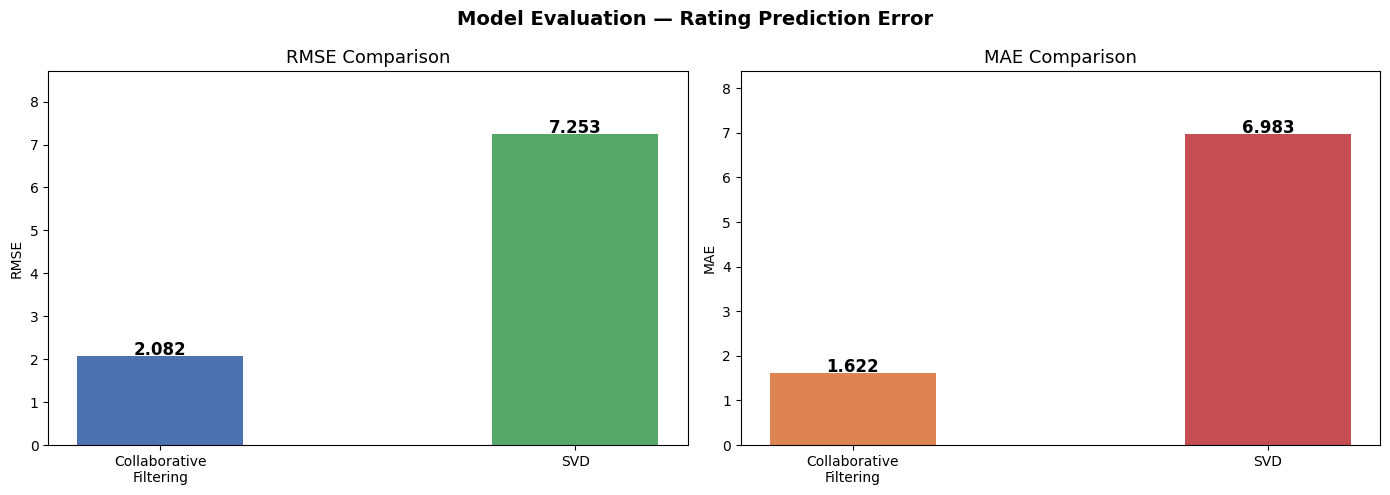

In [43]:
# Plot 1: RMSE comparison for models that support it
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: RMSE
model_names = ['Collaborative\nFiltering', 'SVD']
rmse_vals   = [cf_rmse, svd_rmse]
mae_vals    = [cf_mae, svd_mae]

axes[0].bar(model_names, rmse_vals, color=['#4C72B0','#55A868'], width=0.4)
for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('RMSE Comparison', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmse_vals) * 1.2)

# Bar chart: MAE
axes[1].bar(model_names, mae_vals, color=['#DD8452','#C44E52'], width=0.4)
for i, v in enumerate(mae_vals):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('MAE Comparison', fontsize=13)
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0, max(mae_vals) * 1.2)

plt.suptitle('Model Evaluation — Rating Prediction Error', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

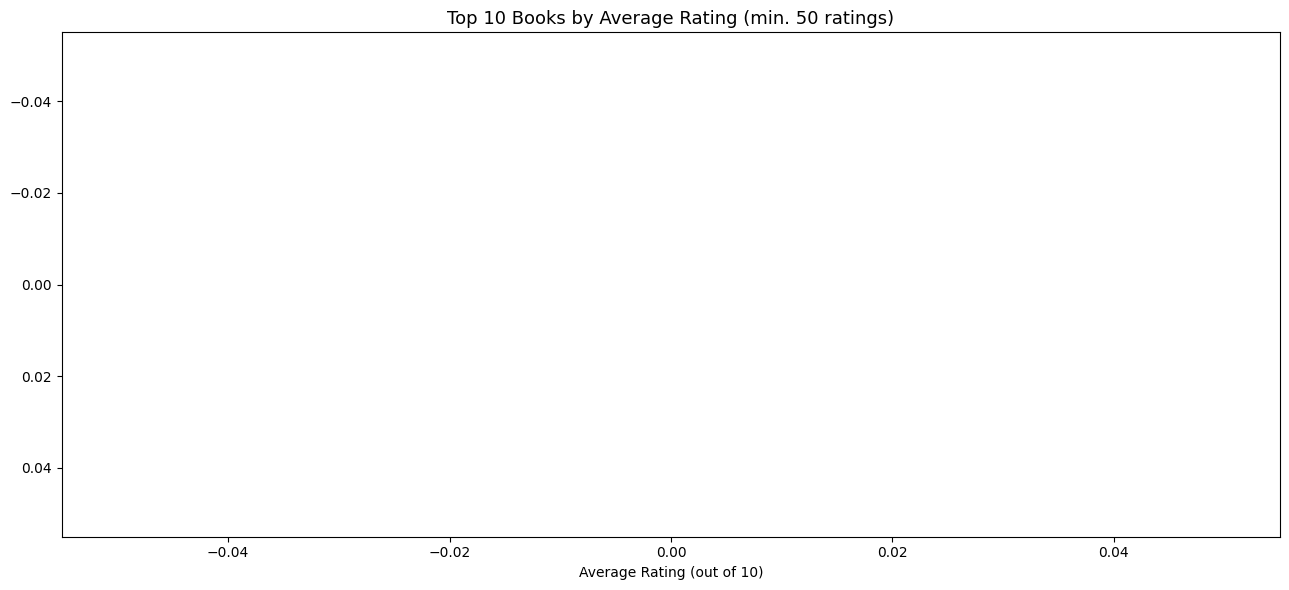

In [44]:
# Plot 2: Top 10 Popular Books
top10 = popularity.head(10)

plt.figure(figsize=(13, 6))
bars = plt.barh(
    top10['Book-Title'].str[:45],
    top10['avg_rating'],
    color=plt.cm.Blues(np.linspace(0.4, 0.9, 10))
)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=9)
plt.xlabel('Average Rating (out of 10)')
plt.title('Top 10 Books by Average Rating (min. 50 ratings)', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

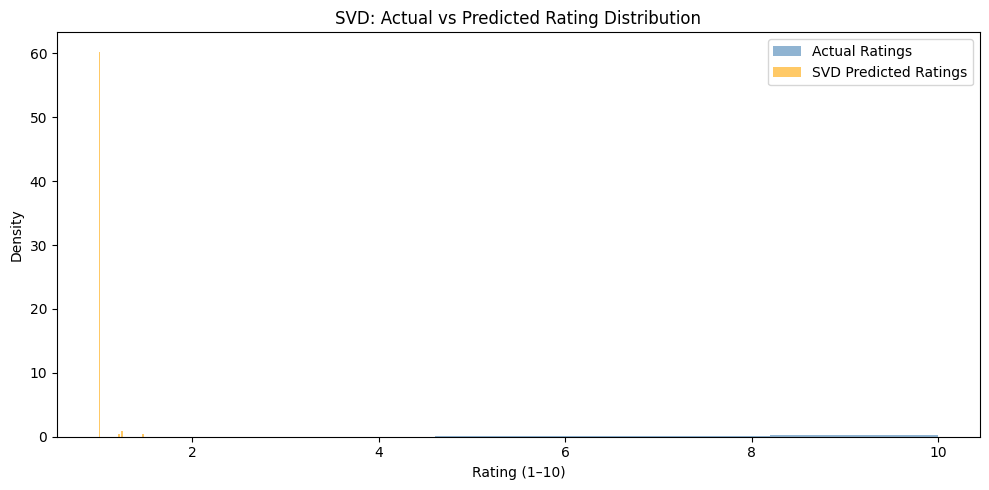

In [45]:
# Plot 3: Distribution of actual vs SVD predicted ratings
plt.figure(figsize=(10, 5))
plt.hist(svd_actual_list, bins=10, alpha=0.6, color='steelblue',
         label='Actual Ratings', density=True)
plt.hist(svd_preds_list, bins=30, alpha=0.6, color='orange',
         label='SVD Predicted Ratings', density=True)
plt.xlabel('Rating (1–10)')
plt.ylabel('Density')
plt.title('SVD: Actual vs Predicted Rating Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
import pickle

pickle.dump(popularity_model, open('popularity.pkl','wb'))
pickle.dump(user_sim_df, open('user_sim_df.pkl','wb'))
pickle.dump(user_book_matrix, open('user_book_matrix.pkl','wb'))
pickle.dump(books_cb, open('books_cb.pkl','wb'))
pickle.dump(tfidf_matrix, open('tfidf_matrix.pkl','wb'))
pickle.dump(title_to_idx, open('title_to_idx.pkl','wb'))

In [50]:
import pandas as pd
import pickle

books = pd.read_csv("Books.csv", encoding="latin-1", low_memory=False)
ratings = pd.read_csv("Ratings.csv", encoding="latin-1", low_memory=False)
users = pd.read_csv("Users.csv", encoding="latin-1", on_bad_lines='skip', engine='python')

df = ratings.merge(books, on="ISBN")
df = df.merge(users, on="User-ID")

df = df[df["Book-Rating"] > 0]

user_counts = df["User-ID"].value_counts()
book_counts = df["ISBN"].value_counts()

filtered_df = df[
    df["User-ID"].isin(user_counts[user_counts >= 5].index)
    &
    df["ISBN"].isin(book_counts[book_counts >= 5].index)
]

cf_data = filtered_df[
    ["User-ID", "Book-Title", "Book-Rating"]
]

pickle.dump(
    cf_data,
    open("cf_data.pkl", "wb")
)

print(cf_data.shape)

(700, 3)


In [48]:
pip install streamlit